In [ ]:
# Notebook ini berfungsi untuk melakukan pembersihan data, menangani nilai kosong, 
# serta mengeksplorasi tren awal penyewaan melalui visualisasi data.

# Tahap ini memastikan dataset sudah melalui proses preprocessing dan 
# rekayasa fitur yang tepat sebelum diolah oleh berbagai model data mining.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv('../data/hour.csv')

# Preprocessing singkat: Ubah dteday ke format datetime
df['dteday'] = pd.to_datetime(df['dteday'])

print("Cuplikan Data")
display(df.head(10))

Cuplikan Data


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [3]:
# Cek Missing Values
print("Missing Values:\n", df.isnull().sum())

# Cek Duplikat
print("\nJumlah Duplikat:", df.duplicated().sum())

Missing Values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah Duplikat: 0


In [4]:

print("Describe  Dataset")
df.describe()

Describe  Dataset


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


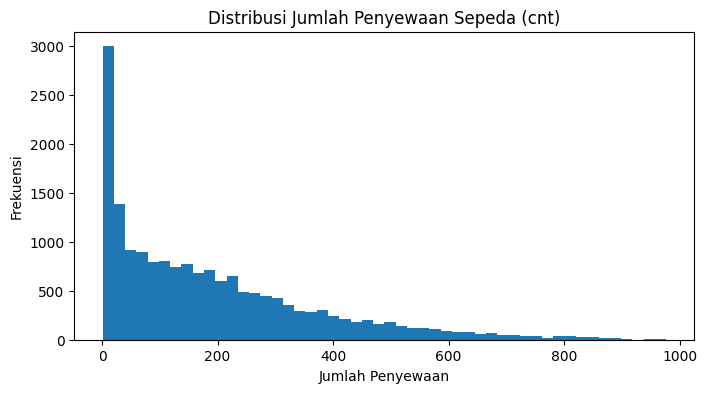

In [5]:
if not os.path.exists('static'):
    os.makedirs('static')

plt.figure(figsize=(8,4))
plt.hist(df['cnt'], bins=50)

plt.title("Distribusi Jumlah Penyewaan Sepeda (cnt)")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")

# Simpan gambar ke folder static sebelum plt.show()
plt.savefig('static/distribusi_penyewaan.png', bbox_inches='tight', dpi=300)

plt.show()

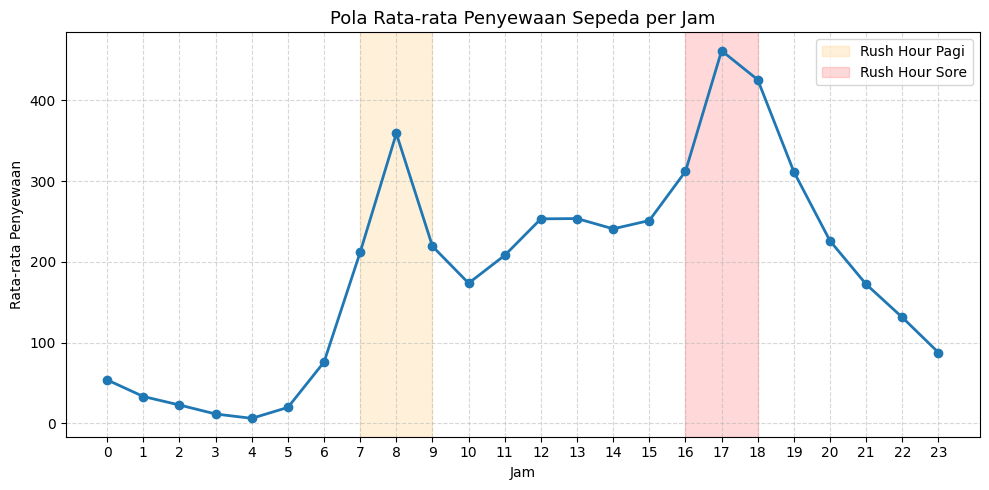

In [6]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Definisikan variabel hourly_avg
hourly_avg = df.groupby('hr')['cnt'].mean()

# 3. Plotting
plt.figure(figsize=(10,5))

plt.plot(
    hourly_avg.index, 
    hourly_avg.values, 
    marker='o', 
    linewidth=2,
    color='tab:blue'
)

# Highlight jam sibuk (Rush Hour)
plt.axvspan(7, 9, color='orange', alpha=0.15, label='Rush Hour Pagi')
plt.axvspan(16, 18, color='red', alpha=0.15, label='Rush Hour Sore')

plt.title("Pola Rata-rata Penyewaan Sepeda per Jam", fontsize=13)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")

plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# --- BAGIAN EXPORT ---
# Simpan ke folder static
plt.savefig('static/pola_jam_penyewaan.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

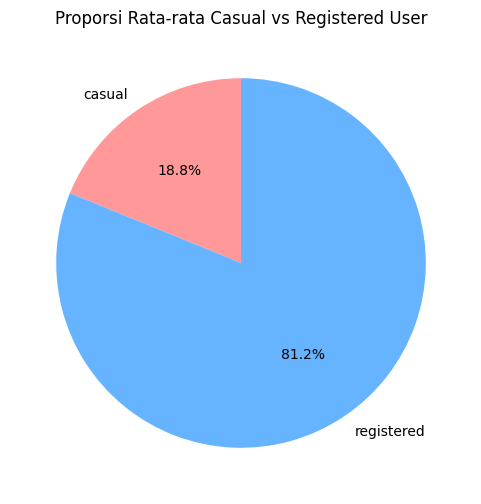

In [10]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Plotting
plt.figure(figsize=(6,6)) # Mengatur ukuran agar pie chart bulat sempurna

df[['casual','registered']].mean().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff'] # Opsional: memberi warna agar lebih estetik
)

plt.title("Proporsi Rata-rata Casual vs Registered User")
plt.ylabel("") # Menghilangkan label 'None' di samping sumbu y

# --- BAGIAN EXPORT ---
# Simpan ke folder static
plt.savefig('static/proporsi_user.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

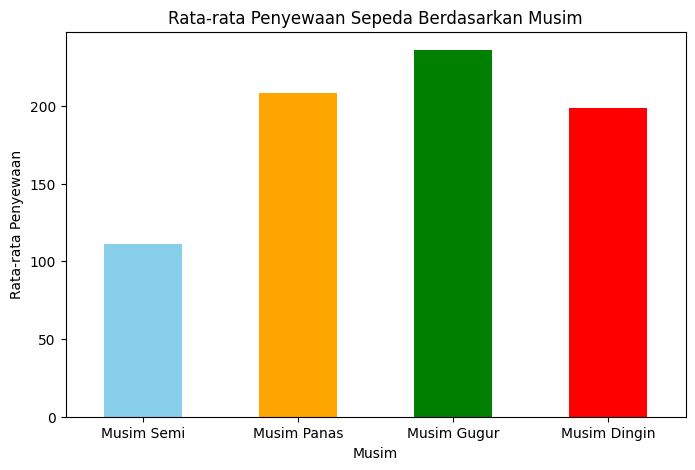

In [15]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Plotting
plt.figure(figsize=(8,5))
ax = df.groupby('season')['cnt'].mean().plot(kind='bar', color=['skyblue', 'orange', 'green', 'red'])

ax.set_xticklabels([
    "Musim Semi",
    "Musim Panas",
    "Musim Gugur",
    "Musim Dingin"
], rotation=0) # rotation=0 supaya tulisan musim tidak miring

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")

# --- BAGIAN EXPORT ---
# Simpan ke folder static
plt.savefig('static/rata_rata_musim.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

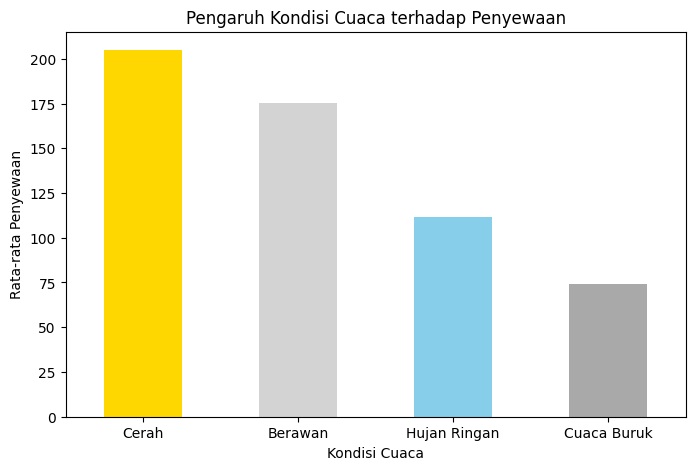

In [18]:
import matplotlib.pyplot as plt
import os

# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Plotting
plt.figure(figsize=(8,5))
ax = df.groupby('weathersit')['cnt'].mean().plot(kind='bar', color=['gold', 'lightgrey', 'skyblue', 'darkgrey'])

ax.set_xticklabels([
    "Cerah",
    "Berawan",
    "Hujan Ringan",
    "Cuaca Buruk"
], rotation=0)

plt.title("Pengaruh Kondisi Cuaca terhadap Penyewaan")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")

# --- BAGIAN EXPORT ---
# Simpan ke folder static
plt.savefig('static/cuaca_vs_penyewaan.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

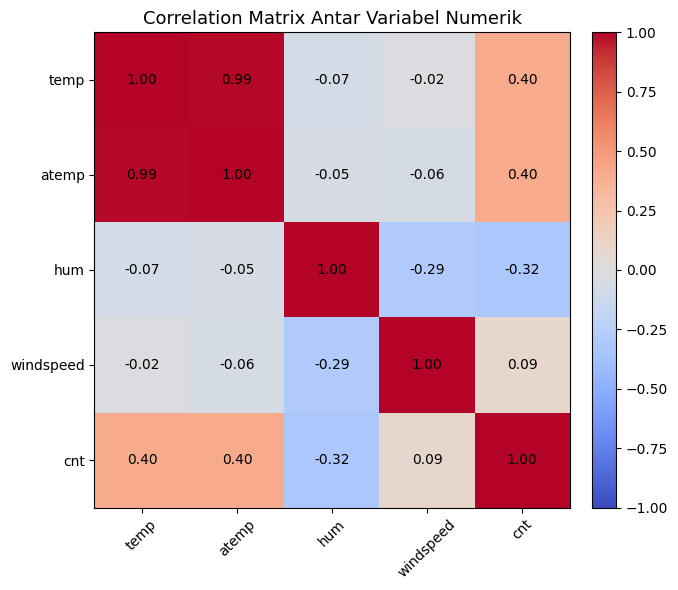

In [19]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Hitung korelasi
corr = df[['temp','atemp','hum','windspeed','cnt']].corr()

# 3. Plotting
plt.figure(figsize=(7,6))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Colorbar
plt.colorbar(im, fraction=0.046, pad=0.04)

# Axis ticks
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)

# Tampilkan nilai korelasi (Angka di dalam kotak)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black'
        )

plt.title("Correlation Matrix Antar Variabel Numerik", fontsize=13)
plt.tight_layout()

# --- BAGIAN EXPORT ---
# Simpan ke folder static sebelum plt.show()
plt.savefig('static/matriks_korelasi.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

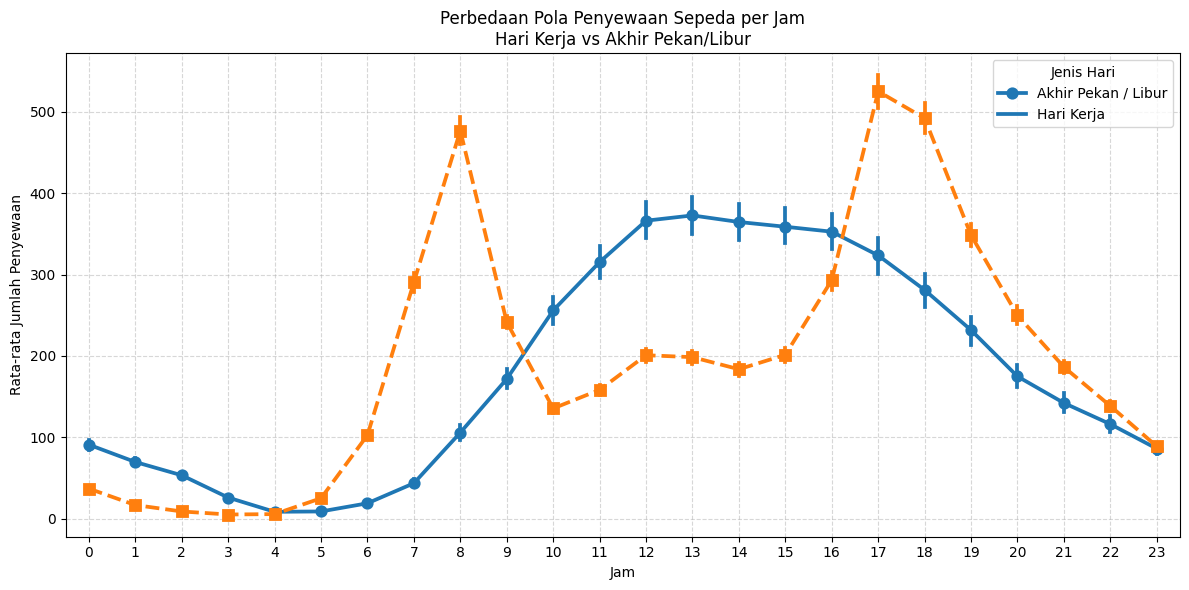

In [22]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Plotting
plt.figure(figsize=(12, 6))

sns.pointplot(
    data=df,
    x='hr',
    y='cnt',
    hue='workingday',
    markers=['o', 's'],
    linestyles=['-', '--']
)

plt.title("Perbedaan Pola Penyewaan Sepeda per Jam\nHari Kerja vs Akhir Pekan/Libur")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Jumlah Penyewaan")

plt.legend(
    title="Jenis Hari",
    labels=["Akhir Pekan / Libur", "Hari Kerja"]
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# --- BAGIAN EXPORT ---
# Simpan ke folder static
plt.savefig('static/pola_kerja_vs_libur.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

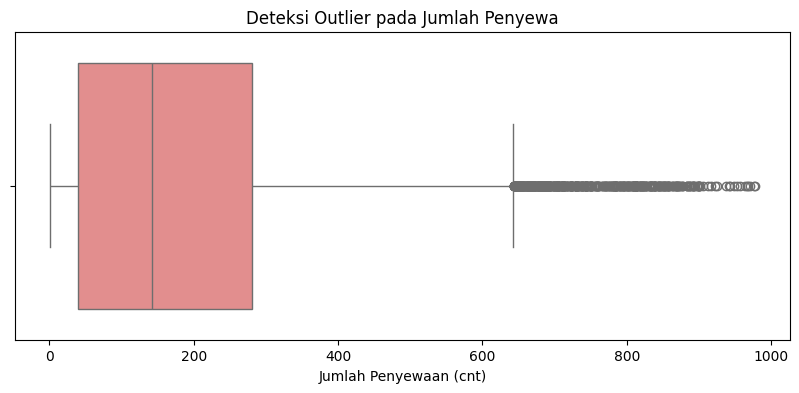

In [27]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Plotting
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['cnt'], color='lightcoral')

plt.title("Deteksi Outlier pada Jumlah Penyewa")
plt.xlabel("Jumlah Penyewaan (cnt)")

# --- BAGIAN EXPORT ---
# Simpan ke folder static
plt.savefig('static/outlier_penyewaan.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

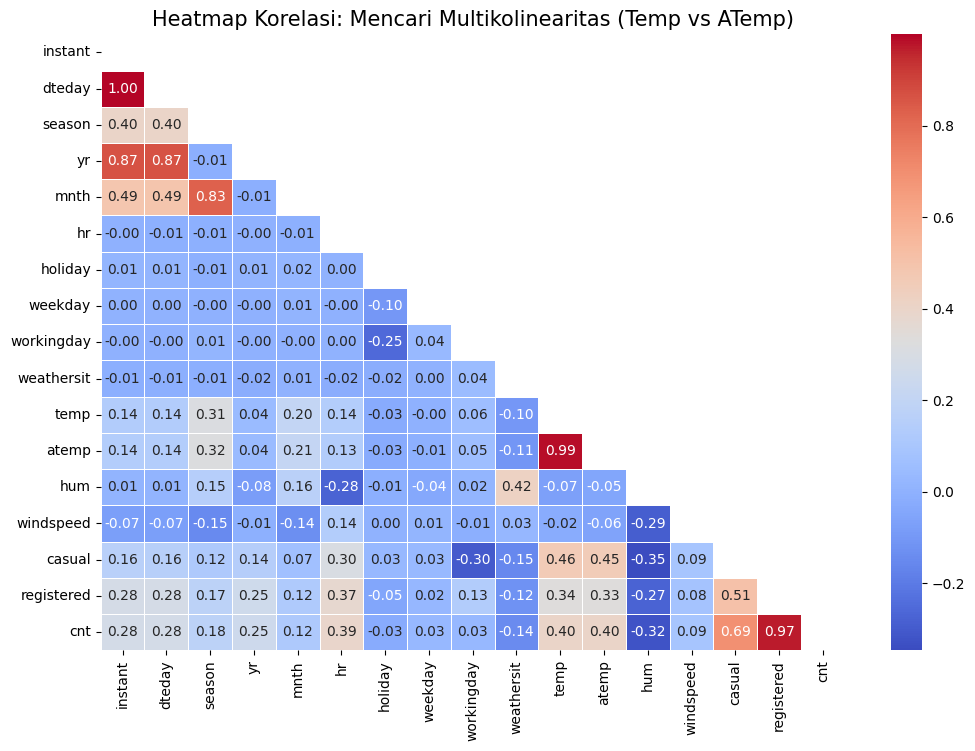

In [28]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Plotting
plt.figure(figsize=(12, 8))

# Membuat mask untuk menyembunyikan sisi atas heatmap agar tidak redundan
mask = np.triu(np.ones_like(df.corr(), dtype=bool))

sns.heatmap(
    df.corr(), 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Heatmap Korelasi: Mencari Multikolinearitas (Temp vs ATemp)", fontsize=15)

# --- BAGIAN EXPORT ---
# Simpan ke folder static
plt.savefig('static/heatmap_regresi.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

C:\Users\REYHAN\AppData\Local\Temp\ipykernel_31184\3049847429.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weathersit', y='cnt', data=df, palette='viridis')


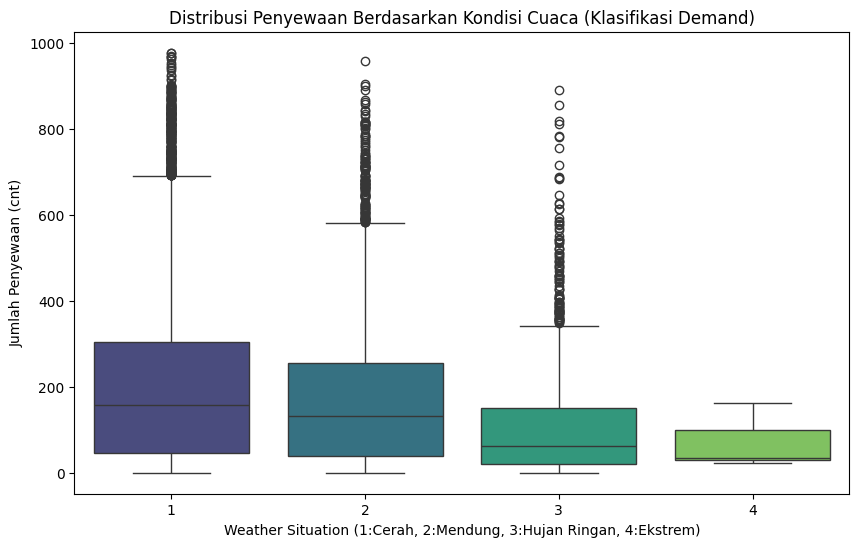

In [31]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# -----------------------------------------------------------------
# PHASE 2: EDA UNTUK KLASIFIKASI (Melihat Pemisahan Kelas)
# -----------------------------------------------------------------
## Fokus: Distribusi penyewaan berdasarkan kondisi cuaca

plt.figure(figsize=(10, 6))

# Saya tambahkan palette warna agar lebih jelas perbedaan tiap kondisi cuaca
sns.boxplot(x='weathersit', y='cnt', data=df, palette='viridis')

plt.title("Distribusi Penyewaan Berdasarkan Kondisi Cuaca (Klasifikasi Demand)")
plt.xlabel("Weather Situation (1:Cerah, 2:Mendung, 3:Hujan Ringan, 4:Ekstrem)")
plt.ylabel("Jumlah Penyewaan (cnt)")

# --- BAGIAN EXPORT ---
# Simpan ke folder static sebelum plt.show()
plt.savefig('static/distribusi_cuaca_klasifikasi.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

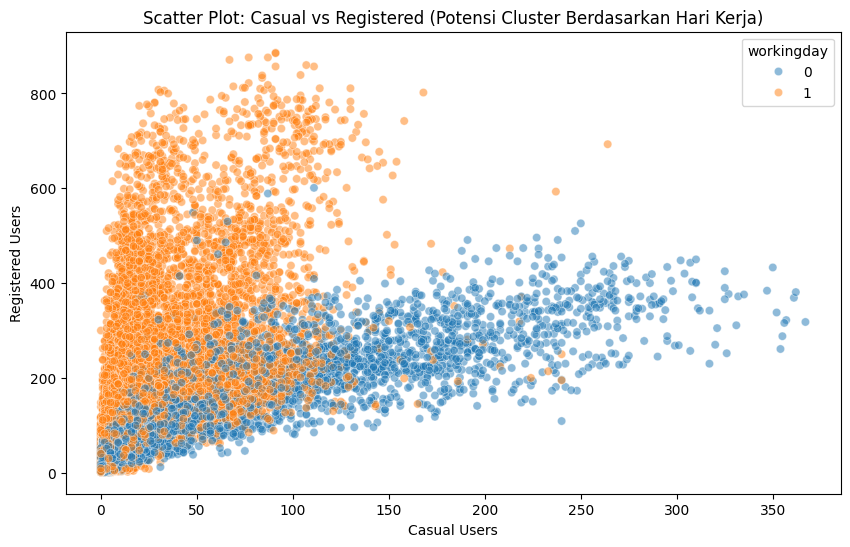

In [32]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# -----------------------------------------------------------------
# PHASE 3: EDA UNTUK CLUSTERING (Segmentasi Pengguna)
# -----------------------------------------------------------------
## Fokus: Perbedaan pola antara pengguna Casual vs Registered

plt.figure(figsize=(10, 6))
sns.scatterplot(x='casual', y='registered', hue='workingday', data=df, alpha=0.5)

plt.title("Scatter Plot: Casual vs Registered (Potensi Cluster Berdasarkan Hari Kerja)")
plt.xlabel("Casual Users")
plt.ylabel("Registered Users")

# --- BAGIAN EXPORT ---
# Simpan ke folder static sebelum plt.show()
plt.savefig('static/segmentasi_user_clustering.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

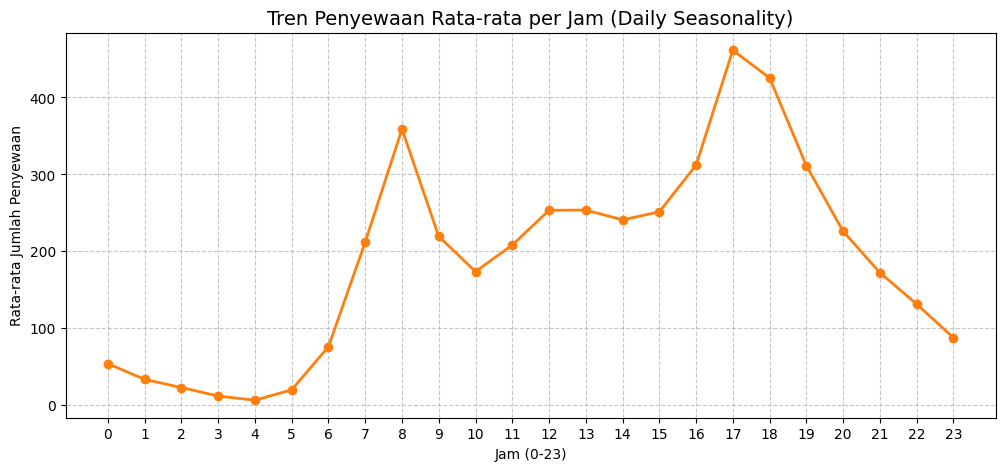

In [33]:
import matplotlib.pyplot as plt
import os

# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# Menghitung rata-rata penyewaan per jam
hourly_trend = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(12, 5))
hourly_trend.plot(kind='line', marker='o', color='tab:orange', linewidth=2)

plt.title("Tren Penyewaan Rata-rata per Jam (Daily Seasonality)", fontsize=14)
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)

# --- BAGIAN EXPORT ---
# Simpan ke folder static sebelum plt.show()
plt.savefig('static/tren_jam_forecasting.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()

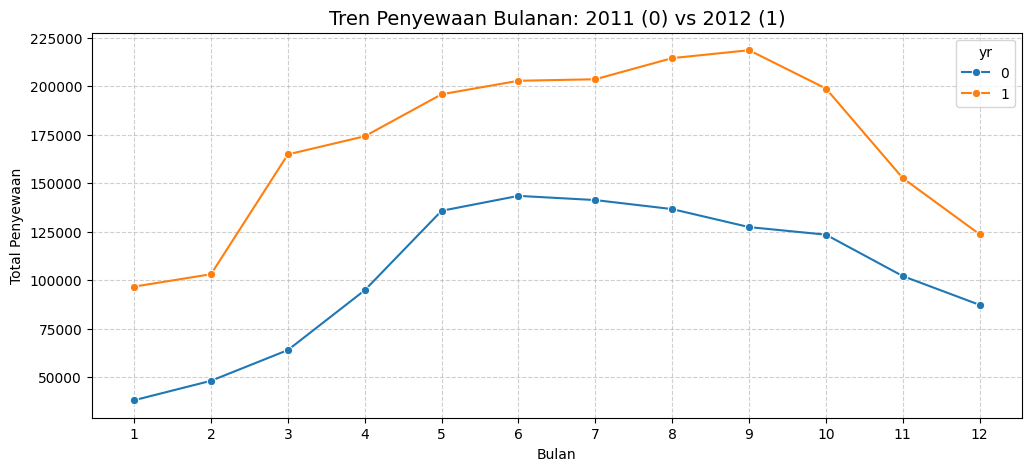

In [34]:
# 1. Pastikan folder 'static' ada
if not os.path.exists('static'):
    os.makedirs('static')

# 2. Hitung data bulanan
monthly_trend = df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 5))
sns.lineplot(x='mnth', y='cnt', hue='yr', data=monthly_trend, marker='o', palette='tab10')

plt.title("Tren Penyewaan Bulanan: 2011 (0) vs 2012 (1)", fontsize=14)
plt.xlabel("Bulan")
plt.ylabel("Total Penyewaan")
plt.xticks(range(1, 13)) # Memastikan label bulan muncul 1-12
plt.grid(True, linestyle='--', alpha=0.6)

# --- BAGIAN EXPORT ---
# Simpan ke folder static sebelum plt.show()
plt.savefig('static/tren_bulanan_forecasting.png', bbox_inches='tight', dpi=300)
# ---------------------

plt.show()